In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print("Veri boyutu:", df.shape)
df.info()

Veri boyutu: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-nu

In [ ]:

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Eksik değer sayıları
print(df.isnull().sum().sort_values(ascending=False).head())

# Boş TotalCharges kayıtlarını göster
df[df["TotalCharges"].isnull()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
].head(15)

TotalCharges     11
gender            0
SeniorCitizen     0
Partner           0
customerID        0
dtype: int64


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [4]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Kimlik sütununu çıkar
df = df.drop(columns="customerID")

# Hedefi 0/1 biçimine getir
df["target"] = (df["Churn"] == "Yes").astype(int)

print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True).round(3))

target
0    5174
1    1869
Name: count, dtype: int64
target
0    0.735
1    0.265
Name: proportion, dtype: float64


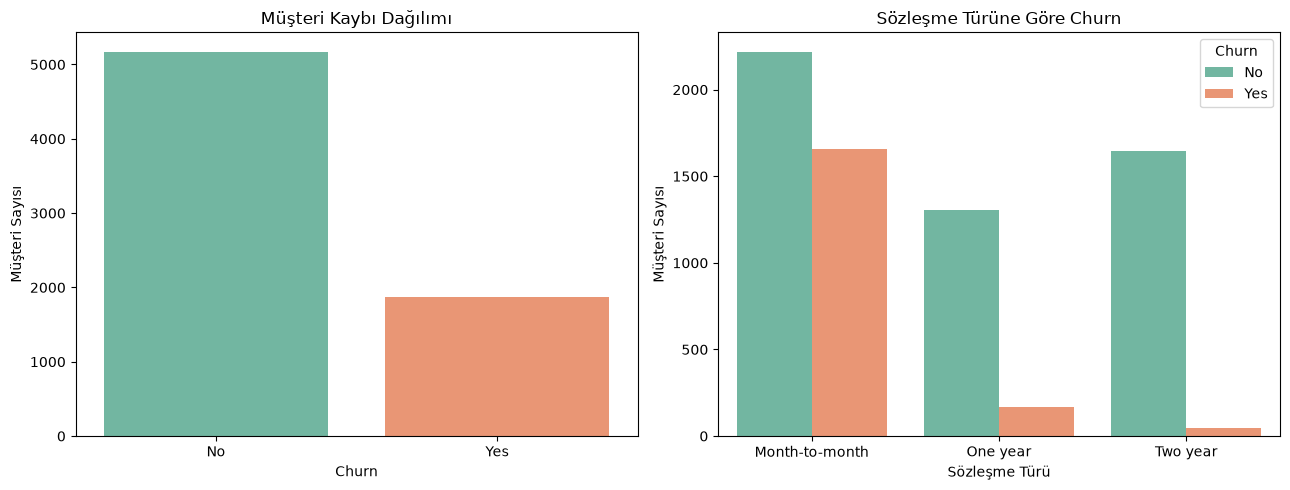

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    palette="Set2",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Müşteri Kaybı Dağılımı")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Müşteri Sayısı")

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn",
    palette="Set2",
    ax=axes[1]
)
axes[1].set_title("Sözleşme Türüne Göre Churn")
axes[1].set_xlabel("Sözleşme Türü")
axes[1].set_ylabel("Müşteri Sayısı")

plt.tight_layout()
plt.show()

In [6]:
contract_churn = (
    df.groupby("Contract")["target"]
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .round(1)
)

print("Sözleşme türüne göre churn oranı (%):")
print(contract_churn)

Sözleşme türüne göre churn oranı (%):
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: target, dtype: float64


In [7]:
# Müşterinin bugüne kadarki tahmini ödemesi
df["EstimatedLifetimeValue"] = df["MonthlyCharges"] * df["tenure"]

# Müşterinin ne kadar yeni olduğunu gösteren özellik
df["IsNewCustomer"] = (df["tenure"] <= 6).astype(int)

# Modelde kullanılmayacak ham hedef sütunu
X = df.drop(columns=["Churn", "target"])
y = df["target"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string", "bool"]).columns.tolist()

print("Sayısal sütunlar:", numeric_features)
print("\nKategorik sütunlar:", categorical_features)

Sayısal sütunlar: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'EstimatedLifetimeValue', 'IsNewCustomer']

Kategorik sütunlar: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Eğitim seti:", X_train.shape)
print("Test seti:", X_test.shape)
print("\nEğitim hedef dağılımı:")
print(y_train.value_counts(normalize=True).round(3))

Eğitim seti: (5634, 21)
Test seti: (1409, 21)

Eğitim hedef dağılımı:
target
0    0.735
1    0.265
Name: proportion, dtype: float64


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

logreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logreg_model.fit(X_train, y_train)

y_pred = logreg_model.predict(X_test)
y_prob = logreg_model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1 Score:", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.739
Precision: 0.505
Recall: 0.794
F1 Score: 0.617
ROC-AUC: 0.846

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Confusion Matrix:

[[744 291]
 [ 77 297]]


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=400,
        max_depth=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest sonuçları")
print("Accuracy:", round(accuracy_score(y_test, rf_pred), 3))
print("Precision:", round(precision_score(y_test, rf_pred), 3))
print("Recall:", round(recall_score(y_test, rf_pred), 3))
print("F1 Score:", round(f1_score(y_test, rf_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 3))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, rf_pred))

Random Forest sonuçları
Accuracy: 0.763
Precision: 0.536
Recall: 0.794
F1 Score: 0.64
ROC-AUC: 0.843

Confusion Matrix:

[[778 257]
 [ 77 297]]


In [11]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import FunctionTransformer

# HistGradientBoostingClassifier yoğun (dense) veri ister
to_dense = FunctionTransformer(
    lambda x: x.toarray() if hasattr(x, "toarray") else x
)

gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("dense", to_dense),
    ("classifier", HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=15,
        l2_regularization=1.0,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting sonuçları")
print("Accuracy:", round(accuracy_score(y_test, gb_pred), 3))
print("Precision:", round(precision_score(y_test, gb_pred), 3))
print("Recall:", round(recall_score(y_test, gb_pred), 3))
print("F1 Score:", round(f1_score(y_test, gb_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, gb_prob), 3))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, gb_pred))

Gradient Boosting sonuçları
Accuracy: 0.802
Precision: 0.663
Recall: 0.516
F1 Score: 0.58
ROC-AUC: 0.837

Confusion Matrix:

[[937  98]
 [181 193]]


In [12]:
from sklearn.model_selection import StratifiedKFold, cross_validate

models = {
    "Logistic Regression": logreg_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, current_model in models.items():
    scores = cross_validate(
        current_model,
        X,
        y,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1 Score": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    "F1 Score",
    ascending=False
).round(3)

display(cv_results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.762,0.536,0.772,0.633,0.846
0,Logistic Regression,0.751,0.520,0.800,0.630,0.847
2,Gradient Boosting,0.797,0.643,0.528,0.579,0.840


In [13]:
# Logistic Regression churn olasılıkları
logreg_prob = logreg_model.predict_proba(X_test)[:, 1]

threshold_results = []

for threshold in [0.50, 0.45, 0.40]:
    threshold_pred = (logreg_prob >= threshold).astype(int)

    threshold_results.append({
        "Eşik": f"%{int(threshold * 100)}",
        "Precision": precision_score(y_test, threshold_pred),
        "Recall": recall_score(y_test, threshold_pred),
        "F1 Score": f1_score(y_test, threshold_pred),
        "Yakalanan Churn": int(
            ((threshold_pred == 1) & (y_test == 1)).sum()
        ),
        "Kaçırılan Churn": int(
            ((threshold_pred == 0) & (y_test == 1)).sum()
        ),
        "Yanlış Alarm": int(
            ((threshold_pred == 1) & (y_test == 0)).sum()
        )
    })

threshold_df = pd.DataFrame(threshold_results).round(3)
display(threshold_df)

,Eşik,Precision,Recall,F1 Score,Yakalanan Churn,Kaçırılan Churn,Yanlış Alarm
0,%50,0.505,0.794,0.617,297,77,291
1,%45,0.492,0.829,0.618,310,64,320
2,%40,0.466,0.877,0.609,328,46,376


In [14]:
# Logistic Regression katsayılarını inceleme

feature_names = logreg_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = logreg_model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    "Abs_Coefficient",
    ascending=False
)

display(coef_df.head(20))

,Feature,Coefficient,Abs_Coefficient
40,cat__Contract_Two year,-0.867538,0.867538
18,cat__InternetService_Fiber optic,0.751376,0.751376
38,cat__Contract_Month-to-month,0.702222,0.702222
17,cat__InternetService_DSL,-0.653209,0.653209
2,num__MonthlyCharges,-0.622553,0.622553
1,num__tenure,-0.594647,0.594647
5,num__IsNewCustomer,0.319228,0.319228
37,cat__StreamingMovies_Yes,0.307492,0.307492
34,cat__StreamingTV_Yes,0.294072,0.294072
19,cat__InternetService_No,-0.288476,0.288476


In [15]:
print("Churn olasılığını artıran özellikler:")
display(
    coef_df
    .sort_values("Coefficient", ascending=False)
    .head(10)
)

print("\nChurn olasılığını azaltan özellikler:")
display(
    coef_df
    .sort_values("Coefficient", ascending=True)
    .head(10)
)

Churn olasılığını artıran özellikler:


,Feature,Coefficient,Abs_Coefficient
18,cat__InternetService_Fiber optic,0.751376,0.751376
38,cat__Contract_Month-to-month,0.702222,0.702222
5,num__IsNewCustomer,0.319228,0.319228
37,cat__StreamingMovies_Yes,0.307492,0.307492
34,cat__StreamingTV_Yes,0.294072,0.294072
3,num__TotalCharges,0.263303,0.263303
45,cat__PaymentMethod_Electronic check,0.232750,0.232750
20,cat__OnlineSecurity_No,0.179125,0.179125
16,cat__MultipleLines_Yes,0.171258,0.171258
29,cat__TechSupport_No,0.148877,0.148877



Churn olasılığını azaltan özellikler:


,Feature,Coefficient,Abs_Coefficient
40,cat__Contract_Two year,-0.867538,0.867538
17,cat__InternetService_DSL,-0.653209,0.653209
2,num__MonthlyCharges,-0.622553,0.622553
1,num__tenure,-0.594647,0.594647
33,cat__StreamingTV_No internet service,-0.288476,0.288476
36,cat__StreamingMovies_No internet service,-0.288476,0.288476
21,cat__OnlineSecurity_No internet service,-0.288476,0.288476
19,cat__InternetService_No,-0.288476,0.288476
27,cat__DeviceProtection_No internet service,-0.288476,0.288476
30,cat__TechSupport_No internet service,-0.288476,0.288476


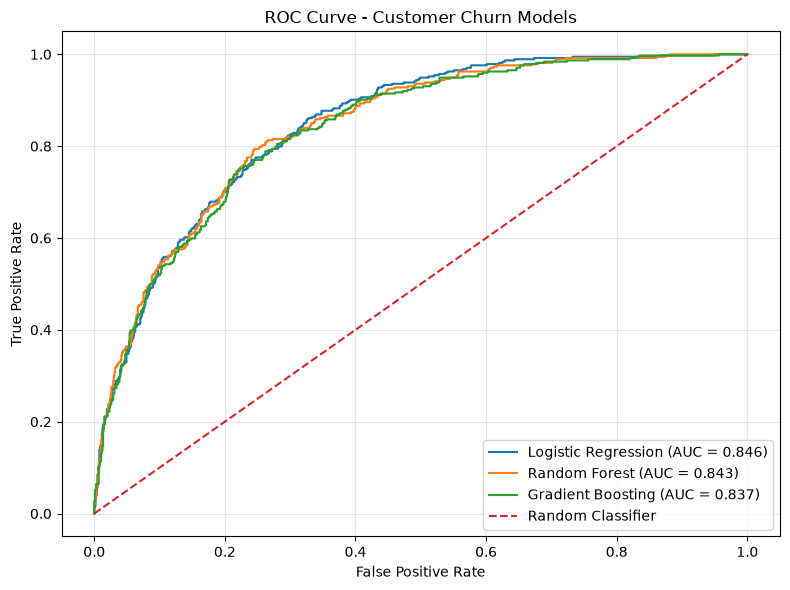

In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Test seti olasılıkları
logreg_prob = logreg_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]
gb_prob = gb_model.predict_proba(X_test)[:, 1]

# ROC değerleri
fpr_log, tpr_log, _ = roc_curve(y_test, logreg_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)

auc_log = auc(fpr_log, tpr_log)
auc_rf = auc(fpr_rf, tpr_rf)
auc_gb = auc(fpr_gb, tpr_gb)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {auc_log:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

plt.plot(
    fpr_gb,
    tpr_gb,
    label=f"Gradient Boosting (AUC = {auc_gb:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn Models")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Average Precision Scores:
Logistic Regression: 0.653
Random Forest: 0.657
Gradient Boosting: 0.648


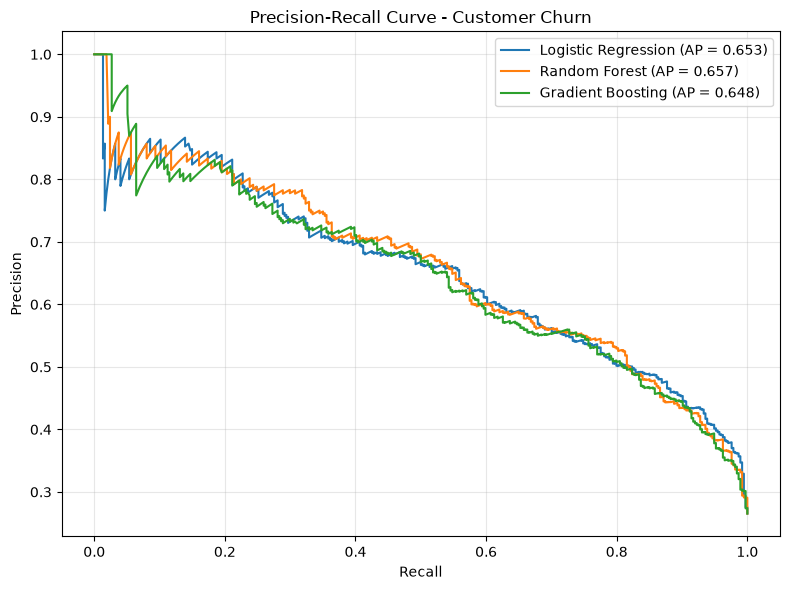

In [17]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Precision-Recall değerleri
precision_log, recall_log, _ = precision_recall_curve(
    y_test,
    logreg_prob
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    rf_prob
)

precision_gb, recall_gb, _ = precision_recall_curve(
    y_test,
    gb_prob
)

# Average Precision
ap_log = average_precision_score(y_test, logreg_prob)
ap_rf = average_precision_score(y_test, rf_prob)
ap_gb = average_precision_score(y_test, gb_prob)

print("Average Precision Scores:")
print("Logistic Regression:", round(ap_log, 3))
print("Random Forest:", round(ap_rf, 3))
print("Gradient Boosting:", round(ap_gb, 3))

# Grafik
plt.figure(figsize=(8, 6))

plt.plot(
    recall_log,
    precision_log,
    label=f"Logistic Regression (AP = {ap_log:.3f})"
)

plt.plot(
    recall_rf,
    precision_rf,
    label=f"Random Forest (AP = {ap_rf:.3f})"
)

plt.plot(
    recall_gb,
    precision_gb,
    label=f"Gradient Boosting (AP = {ap_gb:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Customer Churn")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# Random Forest threshold analizi

rf_threshold_results = []

for threshold in [0.50, 0.45, 0.40]:
    rf_threshold_pred = (rf_prob >= threshold).astype(int)

    rf_threshold_results.append({
        "Eşik": f"%{int(threshold * 100)}",
        "Precision": precision_score(y_test, rf_threshold_pred),
        "Recall": recall_score(y_test, rf_threshold_pred),
        "F1 Score": f1_score(y_test, rf_threshold_pred),
        "Yakalanan Churn": int(
            ((rf_threshold_pred == 1) & (y_test == 1)).sum()
        ),
        "Kaçırılan Churn": int(
            ((rf_threshold_pred == 0) & (y_test == 1)).sum()
        ),
        "Yanlış Alarm": int(
            ((rf_threshold_pred == 1) & (y_test == 0)).sum()
        )
    })

rf_threshold_df = pd.DataFrame(
    rf_threshold_results
).round(3)

display(rf_threshold_df)

,Eşik,Precision,Recall,F1 Score,Yakalanan Churn,Kaçırılan Churn,Yanlış Alarm
0,%50,0.536,0.794,0.640,297,77,257
1,%45,0.513,0.816,0.630,305,69,290
2,%40,0.480,0.840,0.611,314,60,340


In [19]:
# Final Random Forest risk skorları

final_prob = rf_model.predict_proba(X_test)[:, 1]

risk_df = X_test.copy()

risk_df["Churn_Probability"] = final_prob

risk_df["Risk_Level"] = pd.cut(
    risk_df["Churn_Probability"],
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

risk_df["Predicted_Churn"] = (
    risk_df["Churn_Probability"] >= 0.45
).astype(int)

display(
    risk_df[
        ["Churn_Probability", "Risk_Level", "Predicted_Churn"]
    ].head(20)
)

,Churn_Probability,Risk_Level,Predicted_Churn
437,0.025034,Low,0
2280,0.850206,High,1
2235,0.163422,Low,0
4460,0.543701,Medium,1
3761,0.048722,Low,0
5748,0.783335,High,1
3568,0.587827,Medium,1
2976,0.169970,Low,0
5928,0.013295,Low,0
1639,0.568106,Medium,1


In [20]:
# Risk gruplarının dağılımı

risk_counts = (
    risk_df["Risk_Level"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
)

risk_percentage = (
    risk_df["Risk_Level"]
    .value_counts(normalize=True)
    .reindex(["Low", "Medium", "High"])
    * 100
)

risk_summary = pd.DataFrame({
    "Customer_Count": risk_counts,
    "Percentage": risk_percentage.round(2)
})

display(risk_summary)

,Customer_Count,Percentage
Risk_Level,,
Low,635,45.07
Medium,337,23.92
High,437,31.01


In [21]:
# Gerçek churn değerlerini risk_df'ye ekleme

risk_df["Actual_Churn"] = y_test

actual_churn_by_risk = (
    risk_df
    .groupby("Risk_Level", observed=False)["Actual_Churn"]
    .agg(
        Customer_Count="count",
        Actual_Churn_Rate="mean"
    )
)

actual_churn_by_risk["Actual_Churn_Rate"] *= 100

display(
    actual_churn_by_risk.round(2)
)

,Customer_Count,Actual_Churn_Rate
Risk_Level,,
Low,635,5.98
Medium,337,25.52
High,437,57.21


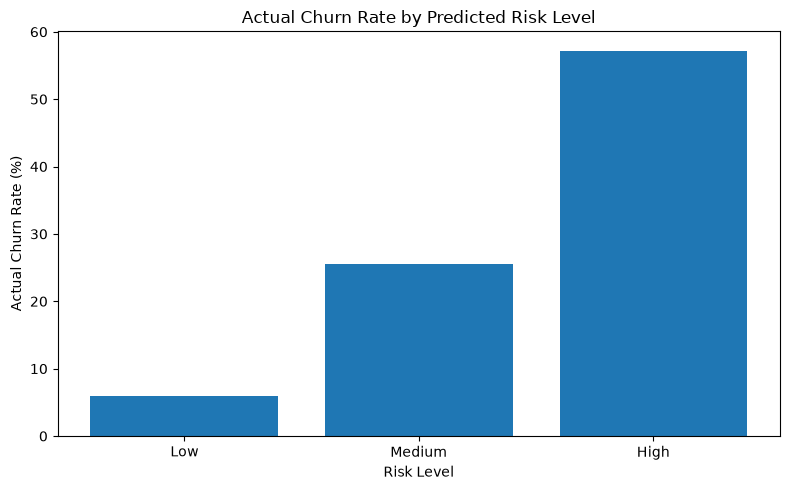

In [22]:
risk_churn_plot = (
    risk_df
    .groupby("Risk_Level", observed=False)["Actual_Churn"]
    .mean()
    .reindex(["Low", "Medium", "High"])
    * 100
)

plt.figure(figsize=(8, 5))

plt.bar(
    risk_churn_plot.index,
    risk_churn_plot.values
)

plt.xlabel("Risk Level")
plt.ylabel("Actual Churn Rate (%)")
plt.title("Actual Churn Rate by Predicted Risk Level")

plt.tight_layout()
plt.show()

In [23]:
# High risk müşterileri
high_risk = risk_df[
    risk_df["Risk_Level"] == "High"
]

print("High Risk müşteri sayısı:", len(high_risk))

display(high_risk.head())

High Risk müşteri sayısı: 437


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,EstimatedLifetimeValue,IsNewCustomer,Churn_Probability,Risk_Level,Predicted_Churn,Actual_Churn
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,...,Yes,Credit card (automatic),100.15,908.55,801.20,0,0.850206,High,1,0
5748,Female,0,No,No,21,Yes,Yes,Fiber optic,No,Yes,...,Yes,Credit card (automatic),99.85,1992.55,2096.85,0,0.783335,High,1,0
3524,Female,1,No,No,11,Yes,Yes,Fiber optic,No,No,...,Yes,Credit card (automatic),84.80,906.85,932.80,0,0.795136,High,1,1
2136,Male,0,No,Yes,15,Yes,Yes,Fiber optic,No,Yes,...,Yes,Electronic check,91.00,1430.05,1365.00,0,0.794791,High,1,0
6529,Male,1,No,No,2,Yes,Yes,Fiber optic,No,No,...,Yes,Mailed check,74.85,156.40,149.70,1,0.879773,High,1,1


In [24]:
# High Risk müşteri profili

high_risk = risk_df[
    risk_df["Risk_Level"] == "High"
].copy()

print("High Risk müşteri sayısı:", len(high_risk))

print("\n--- Sayısal değişkenlerin ortalamaları ---")

numeric_profile = high_risk[
    ["tenure", "MonthlyCharges", "TotalCharges",
     "EstimatedLifetimeValue", "IsNewCustomer"]
].mean()

display(numeric_profile.round(2))

High Risk müşteri sayısı: 437

--- Sayısal değişkenlerin ortalamaları ---


tenure                      13.21
MonthlyCharges              75.88
TotalCharges              1153.79
EstimatedLifetimeValue    1154.57
IsNewCustomer                0.50
dtype: float64

In [25]:
# High Risk kategorik değişken profili

categorical_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling"
]

for feature in categorical_features:
    print(f"\n--- {feature} ---")
    
    profile = (
        high_risk[feature]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
    
    print(profile)


--- Contract ---
Contract
Month-to-month    100.0
Name: proportion, dtype: float64

--- InternetService ---
InternetService
Fiber optic    78.95
DSL            18.54
No              2.52
Name: proportion, dtype: float64

--- PaymentMethod ---
PaymentMethod
Electronic check             62.93
Mailed check                 15.56
Credit card (automatic)      11.44
Bank transfer (automatic)    10.07
Name: proportion, dtype: float64

--- OnlineSecurity ---
OnlineSecurity
No                     88.56
Yes                     8.92
No internet service     2.52
Name: proportion, dtype: float64

--- OnlineBackup ---
OnlineBackup
No                     74.83
Yes                    22.65
No internet service     2.52
Name: proportion, dtype: float64

--- DeviceProtection ---
DeviceProtection
No                     74.14
Yes                    23.34
No internet service     2.52
Name: proportion, dtype: float64

--- TechSupport ---
TechSupport
No                     88.33
Yes                     9.15
N

In [26]:
# High Risk vs tüm test müşterileri

comparison = []

for feature in [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "OnlineSecurity",
    "TechSupport"
]:
    
    high_distribution = (
        high_risk[feature]
        .value_counts(normalize=True)
        .mul(100)
    )
    
    overall_distribution = (
        risk_df[feature]
        .value_counts(normalize=True)
        .mul(100)
    )
    
    for category in high_distribution.index:
        comparison.append({
            "Feature": feature,
            "Category": category,
            "High_Risk_%": high_distribution.get(category, 0),
            "Overall_%": overall_distribution.get(category, 0)
        })

comparison_df = pd.DataFrame(comparison)

comparison_df["Difference"] = (
    comparison_df["High_Risk_%"] -
    comparison_df["Overall_%"]
)

display(
    comparison_df
    .sort_values("Difference", ascending=False)
    .round(2)
)

,Feature,Category,High_Risk_%,Overall_%,Difference
0,Contract,Month-to-month,100.00,54.86,45.14
8,OnlineSecurity,No,88.56,49.75,38.81
11,TechSupport,No,88.33,49.82,38.51
1,InternetService,Fiber optic,78.95,43.51,35.44
4,PaymentMethod,Electronic check,62.93,33.64,29.29
5,PaymentMethod,Mailed check,15.56,23.14,-7.58
6,PaymentMethod,Credit card (automatic),11.44,21.93,-10.49
7,PaymentMethod,Bank transfer (automatic),10.07,21.29,-11.22
2,InternetService,DSL,18.54,34.35,-15.82
12,TechSupport,Yes,9.15,28.03,-18.88


In [27]:
# High Risk grubunda gerçekten churn eden müşteriler

high_risk_churned = high_risk[
    high_risk["Actual_Churn"] == 1
].copy()

high_risk_not_churned = high_risk[
    high_risk["Actual_Churn"] == 0
].copy()

print("High Risk toplam:", len(high_risk))
print("High Risk + gerçekten churn:", len(high_risk_churned))
print("High Risk + churn etmeyen:", len(high_risk_not_churned))

print(
    "\nHigh Risk içindeki gerçek churn oranı:",
    round(high_risk_churned.shape[0] / high_risk.shape[0] * 100, 2),
    "%"
)

High Risk toplam: 437
High Risk + gerçekten churn: 250
High Risk + churn etmeyen: 187

High Risk içindeki gerçek churn oranı: 57.21 %


In [28]:
# Gerçekten churn eden High Risk müşterilerin sayısal profili

high_risk_churn_profile = high_risk_churned[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "EstimatedLifetimeValue",
        "IsNewCustomer"
    ]
].mean()

display(
    high_risk_churn_profile.round(2)
)

tenure                     10.76
MonthlyCharges             75.82
TotalCharges              931.22
EstimatedLifetimeValue    931.11
IsNewCustomer               0.58
dtype: float64

In [29]:
categorical_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling"
]

for feature in categorical_features:
    print(f"\n--- {feature} ---")
    
    profile = (
        high_risk_churned[feature]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
    
    print(profile)


--- Contract ---
Contract
Month-to-month    100.0
Name: proportion, dtype: float64

--- InternetService ---
InternetService
Fiber optic    80.4
DSL            18.0
No              1.6
Name: proportion, dtype: float64

--- PaymentMethod ---
PaymentMethod
Electronic check             66.8
Mailed check                 12.0
Credit card (automatic)      10.8
Bank transfer (automatic)    10.4
Name: proportion, dtype: float64

--- OnlineSecurity ---
OnlineSecurity
No                     92.0
Yes                     6.4
No internet service     1.6
Name: proportion, dtype: float64

--- OnlineBackup ---
OnlineBackup
No                     77.6
Yes                    20.8
No internet service     1.6
Name: proportion, dtype: float64

--- DeviceProtection ---
DeviceProtection
No                     74.0
Yes                    24.4
No internet service     1.6
Name: proportion, dtype: float64

--- TechSupport ---
TechSupport
No                     92.4
Yes                     6.0
No internet service

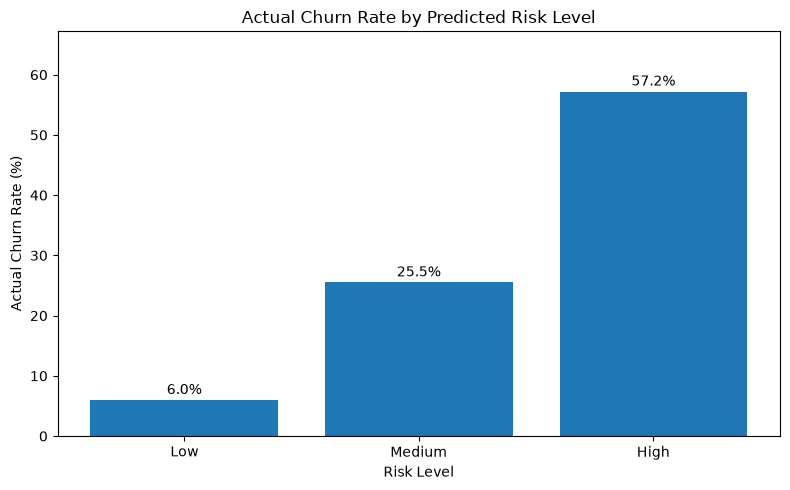

In [30]:
risk_churn_plot = (
    risk_df
    .groupby("Risk_Level", observed=False)["Actual_Churn"]
    .mean()
    .reindex(["Low", "Medium", "High"])
    * 100
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    risk_churn_plot.index,
    risk_churn_plot.values
)

plt.xlabel("Risk Level")
plt.ylabel("Actual Churn Rate (%)")
plt.title("Actual Churn Rate by Predicted Risk Level")

for bar, value in zip(bars, risk_churn_plot.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.ylim(0, max(risk_churn_plot.values) + 10)
plt.tight_layout()
plt.show()

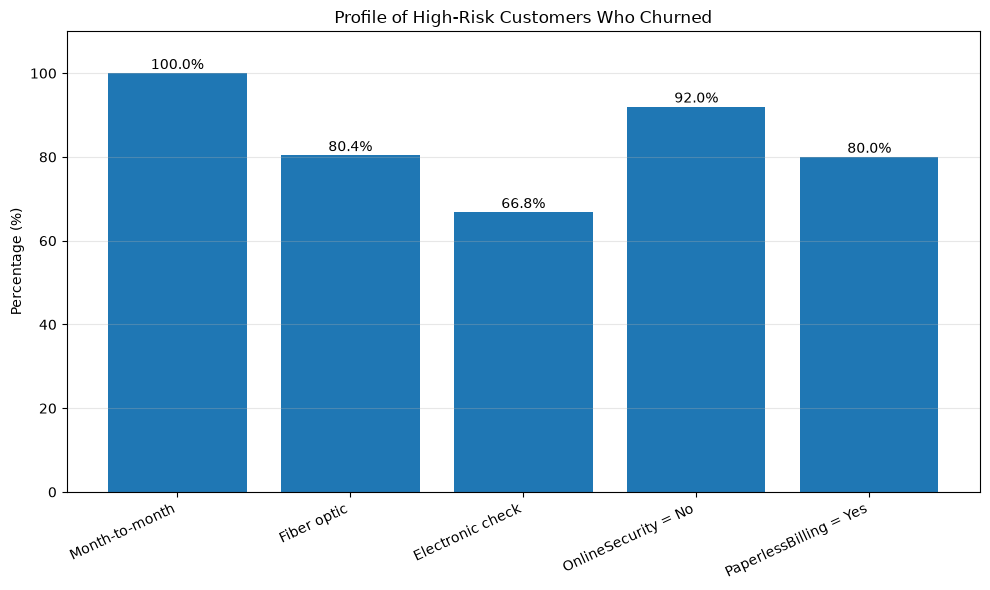

In [31]:
# High Risk + gerçek churn eden müşterilerin önemli özellikleri

profile_data = {
    "Month-to-month": 100.0,
    "Fiber optic": 80.4,
    "Electronic check": 66.8,
    "OnlineSecurity = No": 92.0,
    "PaperlessBilling = Yes": 80.0
}

plt.figure(figsize=(10, 6))

bars = plt.bar(
    profile_data.keys(),
    profile_data.values()
)

plt.ylabel("Percentage (%)")
plt.title("Profile of High-Risk Customers Who Churned")

plt.xticks(
    rotation=25,
    ha="right"
)

for bar, value in zip(bars, profile_data.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.ylim(0, 110)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 700x600 with 0 Axes>

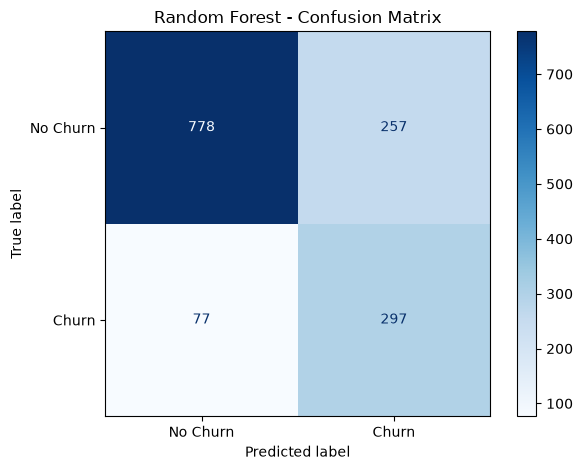

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["No Churn", "Churn"],
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

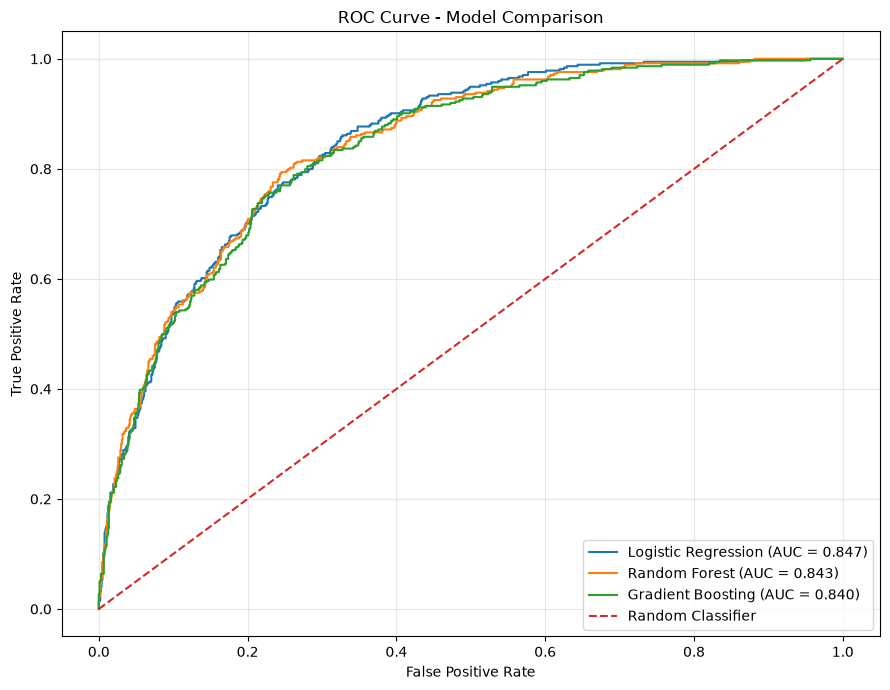

In [34]:
from sklearn.metrics import roc_curve, auc

logreg_fpr, logreg_tpr, _ = roc_curve(y_test, logreg_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(9, 7))

plt.plot(
    logreg_fpr,
    logreg_tpr,
    label="Logistic Regression (AUC = 0.847)"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label="Random Forest (AUC = 0.843)"
)

plt.plot(
    gb_fpr,
    gb_tpr,
    label="Gradient Boosting (AUC = 0.840)"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

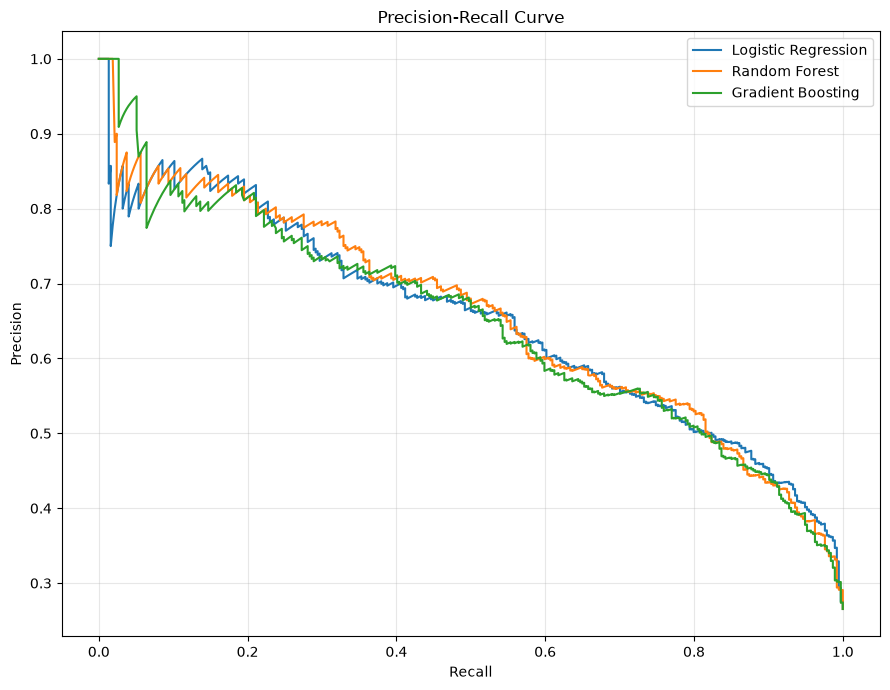

In [35]:
from sklearn.metrics import precision_recall_curve

logreg_precision, logreg_recall, _ = precision_recall_curve(
    y_test,
    logreg_prob
)

rf_precision, rf_recall, _ = precision_recall_curve(
    y_test,
    rf_prob
)

gb_precision, gb_recall, _ = precision_recall_curve(
    y_test,
    gb_prob
)

plt.figure(figsize=(9, 7))

plt.plot(
    logreg_recall,
    logreg_precision,
    label="Logistic Regression"
)

plt.plot(
    rf_recall,
    rf_precision,
    label="Random Forest"
)

plt.plot(
    gb_recall,
    gb_precision,
    label="Gradient Boosting"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
# Random Forest feature importance

rf_preprocessor = rf_model.named_steps["preprocessor"]
rf_classifier = rf_model.named_steps["classifier"]

feature_names = rf_preprocessor.get_feature_names_out()
importances = rf_classifier.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    "Importance",
    ascending=False
)

display(feature_importance_df.head(20))

,Feature,Importance
38,cat__Contract_Month-to-month,0.131907
1,num__tenure,0.096097
3,num__TotalCharges,0.074388
4,num__EstimatedLifetimeValue,0.071183
20,cat__OnlineSecurity_No,0.062680
2,num__MonthlyCharges,0.059408
40,cat__Contract_Two year,0.056626
18,cat__InternetService_Fiber optic,0.047954
29,cat__TechSupport_No,0.047549
45,cat__PaymentMethod_Electronic check,0.033113


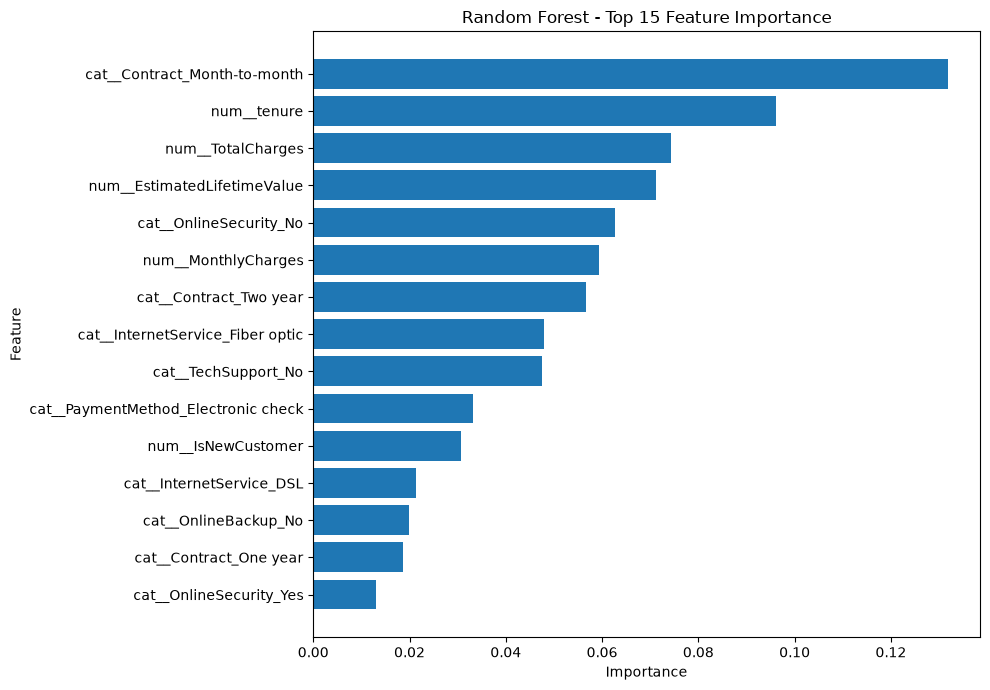

In [37]:
top_features = feature_importance_df.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest - Top 15 Feature Importance")

plt.tight_layout()
plt.show()

# Final Model Evaluation & Business Insights

## Model Selection

Three machine learning models were evaluated for customer churn prediction:

- Logistic Regression
- Random Forest
- Gradient Boosting

Based on ROC-AUC and churn detection performance, Logistic Regression and Random Forest provided the most balanced results.

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Random Forest | 0.762 | 0.536 | 0.772 | 0.633 | 0.846 |
| Logistic Regression | 0.751 | 0.520 | 0.800 | 0.630 | 0.847 |
| Gradient Boosting | 0.797 | 0.643 | 0.528 | 0.579 | 0.840 |

Although Gradient Boosting achieved higher accuracy and precision, its recall was substantially lower. Since missing a customer who is likely to churn is important in a customer retention scenario, Logistic Regression and Random Forest provide a better balance.

Therefore, the final analysis focuses primarily on Logistic Regression and Random Forest.

---

## Threshold Analysis

The default classification threshold of 0.50 was compared with lower thresholds.

| Threshold | Precision | Recall | F1 Score | Detected Churn | Missed Churn | False Alarm |
|---|---:|---:|---:|---:|---:|---:|
| 0.50 | 0.505 | 0.794 | 0.617 | 297 | 77 | 291 |
| 0.45 | 0.492 | 0.829 | 0.618 | 310 | 64 | 320 |
| 0.40 | 0.466 | 0.877 | 0.609 | 328 | 46 | 376 |

Lowering the threshold increases recall and allows the model to identify more customers who are likely to churn. However, this also increases the number of false alarms.

For a customer retention scenario, a threshold around 0.45 can be considered because it improves churn detection while maintaining a similar F1 score.

---

## Key Churn Drivers

According to Logistic Regression coefficients and Random Forest feature importance, the most important churn-related factors include:

- Month-to-month contracts
- Fiber optic internet service
- Short customer tenure
- Monthly charges
- Lack of online security
- Lack of technical support
- Electronic check payment method
- New customer status

Customers with month-to-month contracts showed a substantially higher churn rate than customers with longer contracts.

Contract-based churn rates:

- Month-to-month: 42.7%
- One year: 11.3%
- Two year: 2.8%

This indicates that contract duration is one of the strongest indicators of customer retention.

---

## Customer Risk Segmentation

Customers were divided into three risk groups based on predicted churn probability.

| Risk Level | Customers | Percentage | Actual Churn Rate |
|---|---:|---:|---:|
| Low | 635 | 45.07% | 5.98% |
| Medium | 337 | 23.92% | 25.52% |
| High | 437 | 31.01% | 57.21% |

The high-risk group contains 437 customers.

Among these:

- 250 customers actually churned
- 187 customers did not churn
- Actual churn rate: 57.21%

This demonstrates that the risk segmentation can effectively distinguish customers with substantially different churn probabilities.

---

## High-Risk Customer Profile

The high-risk customer group has the following characteristics:

- Average tenure: approximately 10.8 months
- Average monthly charge: approximately 75.8
- 100% month-to-month contracts
- Approximately 80% use Fiber optic internet
- Approximately 67% use Electronic check
- Approximately 92% have no OnlineSecurity
- Approximately 89% have no TechSupport
- Approximately 80% use PaperlessBilling

These characteristics provide actionable information for customer retention strategies.

---

## Business Recommendations

Based on the analysis, the following retention strategies can be considered:

1. Encourage month-to-month customers to switch to one-year or two-year contracts.
2. Provide targeted retention offers to customers with high monthly charges.
3. Offer discounts or incentives to new customers during the first months of their subscription.
4. Promote OnlineSecurity and TechSupport services to customers who do not currently use them.
5. Monitor customers using electronic check payment methods.
6. Prioritize high-risk customers for proactive retention campaigns.
7. Use the predicted churn probability to prioritize limited customer retention resources.

---

## Conclusion

The analysis demonstrates that machine learning can be used to identify customers who are more likely to churn.

The most important factors are related to contract type, customer tenure, internet service, monthly charges, and additional support services.

The risk segmentation approach provides a practical way to transform model predictions into actionable customer retention strategies.

In [38]:
print(logreg_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'EstimatedLifetimeValue',
                                                   'IsNewCustomer']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   Si

In [39]:
import joblib
from pathlib import Path

model_path = Path("../models/churn_model.pkl")

joblib.dump(logreg_model, model_path)

print(f"Model kaydedildi: {model_path}")

Model kaydedildi: ..\models\churn_model.pkl
